# Prototype 4 — Realistic Strategy Backtest

The first three prototypes established that large single-day declines are followed by unusual short-term price behaviour. Prototype 3 found a particularly strong one-day rebound, followed by weaker performance over the three- to five-day horizon and some evidence of recovery by Day 10.

However, those earlier experiments measured returns from the **event-day closing price**. A real trading system cannot know that a stock has officially closed at least 8% down until the trading session has ended.

Prototype 4 makes the first transition from an **event study** to an **executable trading rule**.

### Core Trading Logic

1. A signal is generated when a stock closes at least **8% below its previous adjusted close**.
2. The strategy waits until the **next trading day**.
3. A position is entered at that day's **opening price**.
4. Several simple exit rules are tested.
5. Only one position in the same stock may be active at a time.

### Strategies Tested

- **1-session hold**: enter at the next open and exit at that day's close.
- **3-session hold**: enter at the next open and exit at the close of the third trading session.
- **5-session hold**: enter at the next open and exit at the close of the fifth trading session.
- **10-session hold**: enter at the next open and exit at the close of the tenth trading session.
- **5% take-profit / 10-session maximum**: exit as soon as the stock trades 5% above the entry price, or otherwise exit at the close of the tenth trading session.

### Parameters and Assumptions

- **Signal threshold**: Daily close-to-close return ≤ -8%
- **Universe**: Same ten large-cap US equities used in Prototypes 1–3
- **Historical period**: 01 January 2016 to 01 January 2026
- **Entry**: Next trading day's adjusted opening price
- **Transaction-cost assumption**: 0.10% per completed round trip
- **Position rule**: Maximum one active position per ticker
- **Take-profit execution assumption**: If the daily high reaches the target, the trade is assumed to exit at the target price
- **No stop-loss is used yet**: Daily OHLC data cannot reliably tell us which level was touched first when both a target and stop occur on the same day. Stop-loss rules will therefore be tested separately in the robustness stage.

## Import Libraries

In [1]:
# If yfinance is not installed, uncomment the next line:
# !pip install yfinance

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Download Adjusted OHLC Data

Earlier prototypes primarily required adjusted closing prices. A trading backtest also needs **Open, High and Low** prices:

- **Open** determines the realistic entry price on the trading day after the signal.
- **High** tells us whether an intraday take-profit target could have been reached.
- **Low** helps measure the worst adverse price movement experienced while a trade was open.
- **Close** provides fixed-horizon and time-based exit prices.

`auto_adjust=True` applies Yahoo! Finance's corporate-action adjustments consistently across the OHLC series. The adjusted `Close` therefore plays the same role as the `Adj Close` series used in the earlier prototypes.

In [2]:
tickers = [
    "AAPL", "MSFT", "AMZN", "GOOGL", "META",
    "JPM", "JNJ", "XOM", "WMT", "NVDA"
]

start_date = "2016-01-01"
end_date = "2026-01-01"

prices = yf.download(
    tickers,
    start=start_date,
    end=end_date,
    auto_adjust=True,
    progress=True
)

open_prices = prices["Open"].copy()
high_prices = prices["High"].copy()
low_prices = prices["Low"].copy()
close_prices = prices["Close"].copy()

close_prices.head()

[*********************100%***********************]  10 of 10 completed


Ticker,AAPL,AMZN,GOOGL,JNJ,JPM,META,MSFT,NVDA,WMT,XOM
Date,,,,,,,,,,
2016-01-04,23.688677,31.849501,37.614079,74.967819,48.184074,101.330170,47.680981,0.788626,16.966858,49.002312
2016-01-05,23.095053,31.689501,37.717594,75.281158,48.267391,101.835724,47.898491,0.801295,17.369905,49.419846
2016-01-06,22.643089,31.632500,37.608635,74.900673,47.570599,102.073654,47.028400,0.768161,17.543827,49.008652
2016-01-07,21.687449,30.396999,36.700768,74.027718,45.646866,97.067612,45.392612,0.737707,17.952400,48.224205
2016-01-08,21.802120,30.352501,36.201027,73.236877,44.624416,96.482735,45.531845,0.721872,17.541063,47.249981


## Generate the Trading Signals

In [3]:
# Calculate adjusted close-to-close daily returns
daily_returns = close_prices.pct_change(fill_method=None)

# A signal occurs after a decline of 8% or more
drop_threshold = -0.08

signals = (
    daily_returns
    .stack()
    .reset_index()
)

signals.columns = ["Date", "Ticker", "Signal_Return"]

signals = signals[
    signals["Signal_Return"] <= drop_threshold
].copy()

signals = signals.sort_values(
    ["Date", "Ticker"]
).reset_index(drop=True)

# Record the closing price that generated the signal
signals["Signal_Close"] = signals.apply(
    lambda row: close_prices.loc[row["Date"], row["Ticker"]],
    axis=1
)

print(f"Number of raw large-drop signals: {len(signals)}")
signals.head(10)

Number of raw large-drop signals: 60


,Date,Ticker,Signal_Return,Signal_Close
0,2017-02-23,NVDA,-0.092723,2.474879
1,2018-02-05,NVDA,-0.084875,5.276874
2,2018-02-20,WMT,-0.101832,27.425871
3,2018-07-26,META,-0.189609,174.725632
4,2018-10-24,NVDA,-0.097937,4.932815
5,2018-11-16,NVDA,-0.187558,4.067515
6,2018-11-19,NVDA,-0.119991,3.579451
7,2018-12-14,JNJ,-0.100379,107.526077
8,2019-01-03,AAPL,-0.099607,33.707928
9,2019-01-28,NVDA,-0.138246,3.417375


## First Check: Where Did the One-Day Rebound Actually Occur?

Prototype 3 found an average **2.10% close-to-close return one trading day after a large-drop event**.

That return can be separated into two components:

1. **Overnight return**: event-day close → next-day open
2. **Entry-day intraday return**: next-day open → next-day close

Only the second component is directly available to a strategy that waits for the large-drop day to finish before entering.

This diagnostic is therefore crucial. If most of the rebound occurs overnight, the statistically strong Day-1 effect may not be practically tradeable using a next-open entry.

In [4]:
def calculate_entry_timing(row):

    ticker = row["Ticker"]
    signal_date = row["Date"]
    signal_close = row["Signal_Close"]

    signal_index = close_prices.index.get_loc(signal_date)

    # If there is no next trading day, the observation cannot be used
    if signal_index + 1 >= len(close_prices.index):
        return pd.Series({
            "Entry_Date": pd.NaT,
            "Next_Open": np.nan,
            "Next_Close": np.nan,
            "Overnight_Return": np.nan,
            "Entry_Day_Intraday_Return": np.nan,
            "Close_to_Close_1D_Return": np.nan
        })

    entry_index = signal_index + 1
    entry_date = close_prices.index[entry_index]

    next_open = open_prices[ticker].iloc[entry_index]
    next_close = close_prices[ticker].iloc[entry_index]

    overnight_return = (
        next_open / signal_close
    ) - 1

    entry_day_intraday_return = (
        next_close / next_open
    ) - 1

    close_to_close_return = (
        next_close / signal_close
    ) - 1

    return pd.Series({
        "Entry_Date": entry_date,
        "Next_Open": next_open,
        "Next_Close": next_close,
        "Overnight_Return": overnight_return,
        "Entry_Day_Intraday_Return": entry_day_intraday_return,
        "Close_to_Close_1D_Return": close_to_close_return
    })

entry_timing = signals.apply(
    calculate_entry_timing,
    axis=1
)

signals_with_timing = pd.concat(
    [signals, entry_timing],
    axis=1
).dropna(
    subset=["Next_Open"]
)

signals_with_timing.head(10)

,Date,Ticker,Signal_Return,Signal_Close,Entry_Date,Next_Open,Next_Close,Overnight_Return,Entry_Day_Intraday_Return,Close_to_Close_1D_Return
0,2017-02-23,NVDA,-0.092723,2.474879,2017-02-24,2.390650,2.498767,-0.034034,0.045225,0.009652
1,2018-02-05,NVDA,-0.084875,5.276874,2018-02-06,5.047228,5.570223,-0.043519,0.103620,0.055591
2,2018-02-20,WMT,-0.101832,27.425871,2018-02-21,27.717298,26.671087,0.010626,-0.037746,-0.027521
3,2018-07-26,META,-0.189609,174.725632,2018-07-27,178.304198,173.367554,0.020481,-0.027687,-0.007773
4,2018-10-24,NVDA,-0.097937,4.932815,2018-10-25,4.835351,5.141348,-0.019758,0.063283,0.042275
5,2018-11-16,NVDA,-0.187558,4.067515,2018-11-19,4.002207,3.579451,-0.016056,-0.105631,-0.119991
6,2018-11-19,NVDA,-0.119991,3.579451,2018-11-20,3.316249,3.687799,-0.073531,0.112039,0.030270
7,2018-12-14,JNJ,-0.100379,107.526077,2018-12-17,103.742429,104.405365,-0.035188,0.006390,-0.029023
8,2019-01-03,AAPL,-0.099607,33.707928,2019-01-04,34.262647,35.146889,0.016457,0.025808,0.042689
9,2019-01-28,NVDA,-0.138246,3.417375,2019-01-29,3.371318,3.258652,-0.013477,-0.033419,-0.046446


In [5]:
timing_summary = pd.DataFrame({
    "Component": [
        "Event close → next open",
        "Next open → next close",
        "Event close → next close"
    ],
    "Mean_Return": [
        signals_with_timing["Overnight_Return"].mean(),
        signals_with_timing["Entry_Day_Intraday_Return"].mean(),
        signals_with_timing["Close_to_Close_1D_Return"].mean()
    ],
    "Median_Return": [
        signals_with_timing["Overnight_Return"].median(),
        signals_with_timing["Entry_Day_Intraday_Return"].median(),
        signals_with_timing["Close_to_Close_1D_Return"].median()
    ],
    "Positive_Rate": [
        (signals_with_timing["Overnight_Return"] > 0).mean(),
        (signals_with_timing["Entry_Day_Intraday_Return"] > 0).mean(),
        (signals_with_timing["Close_to_Close_1D_Return"] > 0).mean()
    ]
})

timing_summary.style.format({
    "Mean_Return": "{:.2%}",
    "Median_Return": "{:.2%}",
    "Positive_Rate": "{:.1%}"
})

,Component,Mean_Return,Median_Return,Positive_Rate
0,Event close → next open,0.76%,1.00%,55.0%
1,Next open → next close,1.34%,0.83%,56.7%
2,Event close → next close,2.10%,1.90%,61.7%


## Build a Fixed-Holding-Period Backtest

The next function converts each signal into an actual trade.

For every qualifying large-drop signal, the function:

1. enters at the **next trading day's open**,
2. exits after a specified number of trading sessions,
3. calculates gross and net return,
4. measures the largest favourable and adverse price movements experienced while the position was open, and
5. prevents a second position in the same ticker from being opened while an earlier trade is still active.

Two additional risk measures are recorded:

- **Maximum Favourable Excursion (MFE)**: the highest return the position reached while it was open.
- **Maximum Adverse Excursion (MAE)**: the lowest return the position reached while it was open.

These do not determine the exit yet. They simply show how much unrealised upside and downside each trade experienced.

In [6]:
# Simplified total cost applied once per completed trade
round_trip_cost = 0.001   # 0.10%

def backtest_fixed_hold(signals_df, hold_sessions):

    trades = []
    skipped_overlapping = 0

    # Tracks when the current position in each stock has finished
    last_exit_date = {}

    for _, row in signals_df.sort_values("Date").iterrows():

        ticker = row["Ticker"]
        signal_date = row["Date"]
        signal_return = row["Signal_Return"]

        signal_index = close_prices.index.get_loc(signal_date)

        entry_index = signal_index + 1
        exit_index = signal_index + hold_sessions

        # Skip signals too close to the end of the dataset
        if exit_index >= len(close_prices.index):
            continue

        entry_date = close_prices.index[entry_index]
        exit_date = close_prices.index[exit_index]

        # A signal at the close of the previous trade's exit day
        # is allowed, because a new position would only open next morning.
        if (
            ticker in last_exit_date
            and signal_date < last_exit_date[ticker]
        ):
            skipped_overlapping += 1
            continue

        entry_price = open_prices[ticker].iloc[entry_index]
        exit_price = close_prices[ticker].iloc[exit_index]

        gross_return = (
            exit_price / entry_price
        ) - 1

        net_return = (
            gross_return - round_trip_cost
        )

        # Price path while the position is active
        trade_highs = high_prices[ticker].iloc[
            entry_index : exit_index + 1
        ]

        trade_lows = low_prices[ticker].iloc[
            entry_index : exit_index + 1
        ]

        max_favourable_excursion = (
            trade_highs.max() / entry_price
        ) - 1

        max_adverse_excursion = (
            trade_lows.min() / entry_price
        ) - 1

        trades.append({
            "Signal_Date": signal_date,
            "Ticker": ticker,
            "Signal_Return": signal_return,
            "Entry_Date": entry_date,
            "Entry_Price": entry_price,
            "Exit_Date": exit_date,
            "Exit_Price": exit_price,
            "Exit_Reason": f"{hold_sessions}-session close",
            "Holding_Sessions": hold_sessions,
            "Gross_Return": gross_return,
            "Net_Return": net_return,
            "MFE": max_favourable_excursion,
            "MAE": max_adverse_excursion
        })

        last_exit_date[ticker] = exit_date

    return pd.DataFrame(trades), skipped_overlapping

## Run the Fixed-Hold Strategies

In [7]:
fixed_horizons = [1, 3, 5, 10]

strategy_trades = {}
skipped_signals = {}

for hold_sessions in fixed_horizons:

    strategy_name = f"Hold {hold_sessions} session"

    if hold_sessions > 1:
        strategy_name += "s"

    trades, skipped = backtest_fixed_hold(
        signals,
        hold_sessions=hold_sessions
    )

    strategy_trades[strategy_name] = trades
    skipped_signals[strategy_name] = skipped

    print(
        f"{strategy_name}: "
        f"{len(trades)} trades, "
        f"{skipped} overlapping signals skipped"
    )

Hold 1 session: 60 trades, 0 overlapping signals skipped
Hold 3 sessions: 51 trades, 9 overlapping signals skipped
Hold 5 sessions: 49 trades, 11 overlapping signals skipped
Hold 10 sessions: 47 trades, 13 overlapping signals skipped


## Build the Take-Profit Strategy

The fixed-hold strategies exit at predetermined times regardless of what happens to the stock.

The next strategy instead asks whether the large post-drop price swings identified in Prototype 3 can be exploited with a simple target:

- Enter at the next day's open.
- Set a take-profit price **5% above the entry price**.
- Starting on the entry day, check each day's adjusted high.
- Exit at the target price on the first day the high reaches that level.
- If the target is never reached, exit at the close of the tenth trading session.

Because only daily OHLC data is available, the precise intraday path is unknown. The backtest therefore assumes that a target was executable if that day's high reached or exceeded it.

In [8]:
def backtest_take_profit(
    signals_df,
    target_return=0.05,
    max_hold_sessions=10
):

    trades = []
    skipped_overlapping = 0
    last_exit_date = {}

    for _, row in signals_df.sort_values("Date").iterrows():

        ticker = row["Ticker"]
        signal_date = row["Date"]
        signal_return = row["Signal_Return"]

        signal_index = close_prices.index.get_loc(signal_date)
        entry_index = signal_index + 1

        # The final possible exit is the 10th trading session after entry begins
        final_exit_index = (
            entry_index + max_hold_sessions - 1
        )

        if final_exit_index >= len(close_prices.index):
            continue

        entry_date = close_prices.index[entry_index]

        if (
            ticker in last_exit_date
            and signal_date < last_exit_date[ticker]
        ):
            skipped_overlapping += 1
            continue

        entry_price = open_prices[ticker].iloc[entry_index]
        target_price = entry_price * (1 + target_return)

        # Examine daily highs from the entry session through the maximum holding period
        possible_highs = high_prices[ticker].iloc[
            entry_index : final_exit_index + 1
        ]

        target_hits = possible_highs[
            possible_highs >= target_price
        ]

        if len(target_hits) > 0:

            # First day on which the target becomes achievable
            exit_date = target_hits.index[0]
            exit_index = close_prices.index.get_loc(exit_date)

            # Assume execution at the target itself
            exit_price = target_price
            exit_reason = "Take profit"

        else:

            exit_index = final_exit_index
            exit_date = close_prices.index[exit_index]
            exit_price = close_prices[ticker].iloc[exit_index]
            exit_reason = "Maximum holding period"

        holding_sessions = (
            exit_index - entry_index + 1
        )

        gross_return = (
            exit_price / entry_price
        ) - 1

        net_return = (
            gross_return - round_trip_cost
        )

        trade_highs = high_prices[ticker].iloc[
            entry_index : exit_index + 1
        ]

        trade_lows = low_prices[ticker].iloc[
            entry_index : exit_index + 1
        ]

        max_favourable_excursion = (
            trade_highs.max() / entry_price
        ) - 1

        max_adverse_excursion = (
            trade_lows.min() / entry_price
        ) - 1

        trades.append({
            "Signal_Date": signal_date,
            "Ticker": ticker,
            "Signal_Return": signal_return,
            "Entry_Date": entry_date,
            "Entry_Price": entry_price,
            "Exit_Date": exit_date,
            "Exit_Price": exit_price,
            "Exit_Reason": exit_reason,
            "Holding_Sessions": holding_sessions,
            "Gross_Return": gross_return,
            "Net_Return": net_return,
            "MFE": max_favourable_excursion,
            "MAE": max_adverse_excursion
        })

        last_exit_date[ticker] = exit_date

    return pd.DataFrame(trades), skipped_overlapping

In [9]:
take_profit_trades, take_profit_skipped = backtest_take_profit(
    signals,
    target_return=0.05,
    max_hold_sessions=10
)

strategy_trades["5% TP / 10-session max"] = take_profit_trades
skipped_signals["5% TP / 10-session max"] = take_profit_skipped

print(
    f"5% TP / 10-session max: "
    f"{len(take_profit_trades)} trades, "
    f"{take_profit_skipped} overlapping signals skipped"
)

take_profit_trades.head(15).style.format({
    "Signal_Return": "{:.2%}",
    "Entry_Price": "${:.2f}",
    "Exit_Price": "${:.2f}",
    "Gross_Return": "{:.2%}",
    "Net_Return": "{:.2%}",
    "MFE": "{:.2%}",
    "MAE": "{:.2%}"
})

5% TP / 10-session max: 52 trades, 8 overlapping signals skipped


,Signal_Date,Ticker,Signal_Return,Entry_Date,Entry_Price,Exit_Date,Exit_Price,Exit_Reason,Holding_Sessions,Gross_Return,Net_Return,MFE,MAE
0,2017-02-23 00:00:00,NVDA,-9.27%,2017-02-24 00:00:00,$2.39,2017-02-24 00:00:00,$2.51,Take profit,1,5.00%,4.90%,5.08%,-1.41%
1,2018-02-05 00:00:00,NVDA,-8.49%,2018-02-06 00:00:00,$5.05,2018-02-06 00:00:00,$5.30,Take profit,1,5.00%,4.90%,10.42%,-0.20%
2,2018-02-20 00:00:00,WMT,-10.18%,2018-02-21 00:00:00,$27.72,2018-03-06 00:00:00,$25.95,Maximum holding period,10,-6.36%,-6.46%,0.24%,-8.27%
3,2018-07-26 00:00:00,META,-18.96%,2018-07-27 00:00:00,$178.30,2018-08-09 00:00:00,$181.50,Maximum holding period,10,1.79%,1.69%,4.69%,-7.40%
4,2018-10-24 00:00:00,NVDA,-9.79%,2018-10-25 00:00:00,$4.84,2018-10-25 00:00:00,$5.08,Take profit,1,5.00%,4.90%,7.31%,-0.92%
5,2018-11-16 00:00:00,NVDA,-18.76%,2018-11-19 00:00:00,$4.00,2018-12-03 00:00:00,$4.20,Take profit,10,5.00%,4.90%,8.08%,-17.60%
6,2018-12-14 00:00:00,JNJ,-10.04%,2018-12-17 00:00:00,$103.74,2018-12-31 00:00:00,$104.33,Maximum holding period,10,0.57%,0.47%,3.49%,-5.70%
7,2019-01-03 00:00:00,AAPL,-9.96%,2019-01-04 00:00:00,$34.26,2019-01-08 00:00:00,$35.98,Take profit,3,5.00%,4.90%,5.04%,-0.51%
8,2019-01-28 00:00:00,NVDA,-13.82%,2019-01-29 00:00:00,$3.37,2019-01-31 00:00:00,$3.54,Take profit,3,5.00%,4.90%,6.64%,-3.78%
9,2020-03-09 00:00:00,JPM,-13.55%,2020-03-10 00:00:00,$83.26,2020-03-13 00:00:00,$87.42,Take profit,4,5.00%,4.90%,5.04%,-12.81%


The table above is the first **trade ledger** in the project.

Each row now represents something a paper-trading system could actually attempt:

**signal → next-day entry → active position → exit → realised return**

This is fundamentally different from the earlier event-study tables, which measured what prices did without imposing executable trading rules.

## Summarise Strategy Performance

In [10]:
def summarise_strategy(
    trades,
    strategy_name,
    skipped_count
):

    returns = trades["Net_Return"].dropna()

    winners = returns[
        returns > 0
    ]

    losers = returns[
        returns < 0
    ]

    if len(losers) > 0:
        profit_factor = (
            winners.sum()
            / abs(losers.sum())
        )
    else:
        profit_factor = np.nan

    return {
        "Strategy": strategy_name,
        "Trades": len(trades),
        "Skipped_Overlap_Signals": skipped_count,
        "Win_Rate": (returns > 0).mean(),
        "Mean_Net_Return": returns.mean(),
        "Median_Net_Return": returns.median(),
        "Profit_Factor": profit_factor,
        "Best_Trade": returns.max(),
        "Worst_Trade": returns.min(),
        "Average_Holding_Sessions": trades[
            "Holding_Sessions"
        ].mean(),
        "Average_MFE": trades["MFE"].mean(),
        "Average_MAE": trades["MAE"].mean()
    }

strategy_summary = pd.DataFrame([
    summarise_strategy(
        trades,
        strategy_name,
        skipped_signals[strategy_name]
    )
    for strategy_name, trades
    in strategy_trades.items()
])

strategy_summary.style.format({
    "Win_Rate": "{:.1%}",
    "Mean_Net_Return": "{:.2%}",
    "Median_Net_Return": "{:.2%}",
    "Profit_Factor": "{:.2f}",
    "Best_Trade": "{:.2%}",
    "Worst_Trade": "{:.2%}",
    "Average_Holding_Sessions": "{:.1f}",
    "Average_MFE": "{:.2%}",
    "Average_MAE": "{:.2%}"
})

,Strategy,Trades,Skipped_Overlap_Signals,Win_Rate,Mean_Net_Return,Median_Net_Return,Profit_Factor,Best_Trade,Worst_Trade,Average_Holding_Sessions,Average_MFE,Average_MAE
0,Hold 1 session,60,0,56.7%,1.24%,0.73%,2.14,11.10%,-10.66%,1.0,3.63%,-3.59%
1,Hold 3 sessions,51,9,31.4%,-2.20%,-2.43%,0.36,13.15%,-19.57%,3.0,4.33%,-6.85%
2,Hold 5 sessions,49,11,28.6%,-2.25%,-3.15%,0.49,14.46%,-25.40%,5.0,5.22%,-8.08%
3,Hold 10 sessions,47,13,48.9%,0.03%,-0.22%,1.01,21.76%,-31.98%,10.0,7.48%,-9.54%
4,5% TP / 10-session max,52,8,63.5%,0.18%,4.90%,1.07,4.90%,-31.98%,6.2,4.97%,-7.95%


### How to Read the Strategy Metrics

- **Win Rate**: percentage of completed trades with a positive net return.
- **Mean Net Return**: average return per trade after the simplified 0.10% round-trip cost.
- **Median Net Return**: the middle trade return; useful for checking whether a few outliers are distorting the mean.
- **Profit Factor**: total percentage gains from winning trades divided by the absolute total percentage losses from losing trades.
    - Above **1.0** means gross winning returns exceed gross losing returns in the sample.
    - Below **1.0** means losses outweigh gains.
- **Best / Worst Trade**: extreme realised outcomes.
- **Average MFE**: average maximum unrealised upside reached while trades were open.
- **Average MAE**: average maximum unrealised downside reached while trades were open.

At this stage, **mean return, median return and profit factor should be considered together**. A high win rate alone does not make a strategy attractive if occasional losses are much larger than typical gains.

## Inspect the Take-Profit Exit Behaviour

In [11]:
take_profit_exit_summary = (
    take_profit_trades
    .groupby("Exit_Reason")
    .agg(
        Trades=("Ticker", "size"),
        Mean_Net_Return=("Net_Return", "mean"),
        Median_Net_Return=("Net_Return", "median"),
        Mean_Holding_Sessions=("Holding_Sessions", "mean")
    )
    .reset_index()
)

take_profit_exit_summary["Share_of_Trades"] = (
    take_profit_exit_summary["Trades"]
    / len(take_profit_trades)
)

take_profit_exit_summary.style.format({
    "Mean_Net_Return": "{:.2%}",
    "Median_Net_Return": "{:.2%}",
    "Mean_Holding_Sessions": "{:.1f}",
    "Share_of_Trades": "{:.1%}"
})

,Exit_Reason,Trades,Mean_Net_Return,Median_Net_Return,Mean_Holding_Sessions,Share_of_Trades
0,Maximum holding period,22,-6.25%,-5.63%,10.0,42.3%
1,Take profit,30,4.90%,4.90%,3.4,57.7%


This breakdown separates trades that successfully reached the 5% target from trades that remained open until the ten-session time limit.

The second group is particularly important. Because successful take-profit trades are capped near +5%, the profitability of the strategy can be dominated by what happens to the **unsuccessful trades** that reach the maximum holding period.

## Visualise the Strategy Comparison

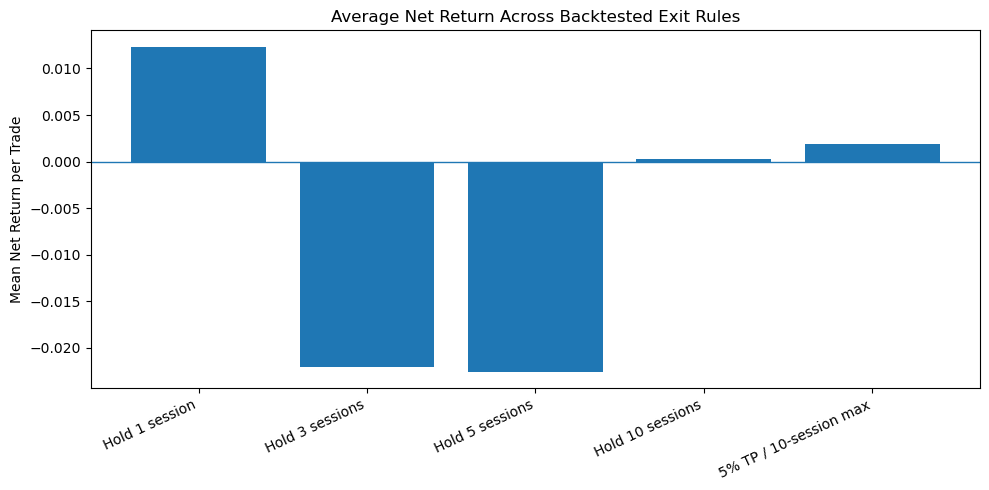

In [12]:
plt.figure(figsize=(10, 5))

plt.bar(
    strategy_summary["Strategy"],
    strategy_summary["Mean_Net_Return"]
)

plt.axhline(
    0,
    linewidth=1
)

plt.ylabel("Mean Net Return per Trade")
plt.title("Average Net Return Across Backtested Exit Rules")
plt.xticks(rotation=25, ha="right")

plt.tight_layout()
plt.show()

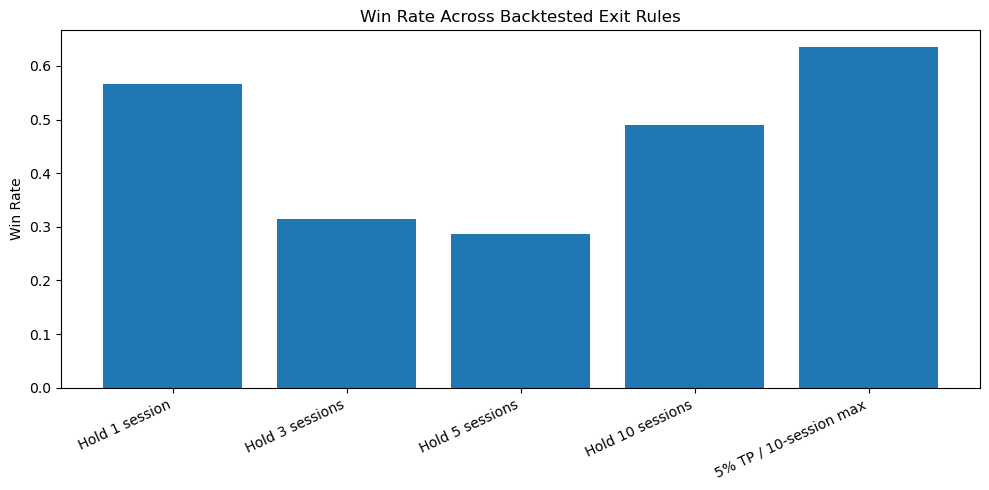

In [13]:
plt.figure(figsize=(10, 5))

plt.bar(
    strategy_summary["Strategy"],
    strategy_summary["Win_Rate"]
)

plt.ylabel("Win Rate")
plt.title("Win Rate Across Backtested Exit Rules")
plt.xticks(rotation=25, ha="right")

plt.tight_layout()
plt.show()

## Results

Prototype 4 shows that the post-drop rebound remains partially tradeable even after using a realistic next-day opening entry.

### Immediate Rebound

The average return from the event-day close to the next open was **0.76%**, while the return from the next open to the next close was **1.34%**. This means that a substantial part of the 2.10% one-day rebound identified in Prototype 3 still occurs after a realistic entry point.

The **one-session hold** was the strongest strategy tested, producing:

- **1.24% mean net return**
- **0.73% median net return**
- **56.7% win rate**
- **2.14 profit factor**

This suggests that the most promising opportunity occurs immediately after the large-drop event.

### Longer Holding Periods

Performance deteriorated sharply over longer holding periods.

The three-session and five-session strategies produced mean net returns of **-2.20%** and **-2.25%**, with win rates of only **31.4%** and **28.6%** respectively.

The ten-session strategy was approximately break-even, with a **0.03% mean net return**, **-0.22% median return**, and a profit factor of **1.01**. This indicates that simply holding for a longer recovery period does not provide a clear advantage.

### Take-Profit Strategy

The 5% take-profit strategy achieved a high **63.5% win rate**, but its average net return was only **0.18%**.

This is explained by the exit behaviour:

- **57.7%** of trades reached the take-profit target, earning approximately **4.90% net**
- **42.3%** reached the maximum holding period and lost an average of **6.25%**

The strategy therefore produces many moderate winners but is vulnerable to fewer, much larger losses.

### Implications

The results suggest that the large-drop signal is best interpreted as a **short-term rebound effect rather than a multi-day mean-reversion strategy**.

The one-session strategy is currently the strongest candidate for further testing. The next step is to test whether this result remains robust across different drop thresholds, stocks, years and market conditions, and whether it outperforms matched ordinary trading days.